# CMIP6 Precipitation Trend Analysis

---

## Overview
This notebook will examine trends in precipitation over the Indian Ocean/Oceana for the historical runs in 5 member models of CMIP6. 

1. Load in CMIP6 data
1. Standardize data
1. Define the geographical region of interest 
1. Mean precipitation time series 1950-2009
1. Annual precipitation cycle
1. Spatial patterns of average precipitation

## Prerequisites

A basic understanding of matplotlib, xarray, and numpy are needed for this notebook. The CMIP6 Cookbook found on the Project Pythia website also provides valuable and relavent information.


| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Helpful | |
| Familiarity with metadata structure| Helpful |  |
| Project management | Helpful | |

- **Time to learn**: 10 minutes
- **System requirements**:
    - Populate with any system, version, or non-Python software requirements if necessary
    - Otherwise use the concepts table above and the Imports section below to describe required packages as necessary
    - If no extra requirements, remove the **System requirements** point altogether

## Imports

In [1]:
import numpy as np
import pandas as pd
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
import xesmf as xe
import warnings
#xr.set_options(display_style='html')
import intake
%matplotlib inline

## Load in CMIP6 data

This section utilizes code from Project Pythia's CMIP6 Notebook on loading in CMIP6 using Intake-ESM

In [2]:
datasets = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
datasets

,unique
activity_id,18
institution_id,36
source_id,88
experiment_id,170
member_id,657
table_id,37
variable_id,700
grid_label,10
zstore,514818
dcpp_init_year,60


#### What do each of these dimensions define?

- activity_id: Experiment in CMIP6 project
- institution_id: Modeling institution
- source_id: Model name
- experiment_id: Model scenario (for example 'historical', 'ssp585', etc.)
- member_id: Ensemble member (r#i#p#f#)
- table_id: Temporal resolution of the data
- variable_id: Variable of interest
- grid_label: Grid type
- zstore: Used for Loading in the dataset
- dcpp_init_year: Initialization year (this is not applicable to all members)
- version: Data version
- derived_variable_id: Specifies of variable is derived (default to 0)

More information can be found here (https://earth-env-data-science.github.io/lectures/models/cmip.html)

#### The following code selects the desired dataset from the vast array of datasets within the pangeo-cmip6 catalog.

The following data attributes are chosen:
- Historical run, monthly resolution, precipitation variable, standard model grid, r1i1p1f1 initial conditions, and the CESM2, AWI-ESM-1-1-LR, BCC-ESM1, NorESM2-LM, and MRI-ESM2-0 models.

In [3]:
datasets.df['grid_label'].unique()

array(['gn', 'gr', 'gr1', 'grz', 'gr2', 'gr2z', 'gr1z', 'gr3', 'gm',
       'gnz'], dtype=object)

In [4]:
cat = datasets.search(experiment_id=['historical'], table_id='Amon', variable_id='pr', 
                    source_id=['CESM2','AWI-ESM-1-1-LR','BCC-ESM1','NorESM2-LM','MRI-ESM2-0'],
grid_label='gn', member_id='r1i1p1f1')

In [5]:
cat.df

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,CMIP,BCC,BCC-ESM1,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/BCC/BCC-ESM1/historical/...,NaN,20181214
1,CMIP,MRI,MRI-ESM2-0,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/MRI/MRI-ESM2-0/historica...,NaN,20190222
2,CMIP,NCAR,CESM2,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r1...,NaN,20190401
3,CMIP,NCC,NorESM2-LM,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/NCC/NorESM2-LM/historica...,NaN,20190815
4,CMIP,AWI,AWI-ESM-1-1-LR,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/AWI/AWI-ESM-1-1-LR/histo...,NaN,20200212


Convert the list of datsets into an xarray contianing all datasets of interest

In [6]:
dset_dict = cat.to_dataset_dict(zarr_kwargs={'consolidated': True})
list(dset_dict.keys())


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


['CMIP.MRI.MRI-ESM2-0.historical.Amon.gn',
 'CMIP.NCC.NorESM2-LM.historical.Amon.gn',
 'CMIP.AWI.AWI-ESM-1-1-LR.historical.Amon.gn',
 'CMIP.NCAR.CESM2.historical.Amon.gn',
 'CMIP.BCC.BCC-ESM1.historical.Amon.gn']

## Standardize Data

Since different CMIP6 model members have different time datatypes and resolutions (lat-lon coordinates) we need to standardize them. In this section we will also filter the data to only include the time frame we are interested in 1950-2009.

Code for regridding the data was modified from here: https://pavics-sdi.readthedocs.io/en/latest/notebooks/regridding.html

:::{note}
The RuntimeWarning that is thrown when converting time indexes arises from discrepancies when accounting for leap years in time indexes. This should not significantly impact the long term analysis we are conducting in this notebook!
:::

In [7]:
## ignore some warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [8]:
## make and xarray Dataset with the standardized lat lons of interest
standard_grid = xr.Dataset(
    coords={'lat': np.arange(-90, 90.1, 1), 'lon': np.arange(0, 360, 1)})

## intialize a list to populate with the standardized data
p = []

## loop through each model
for i in dset_dict.keys():
    ## lets get rid of unecessary dimensions in each dataset
    x = dset_dict[i]['pr'].isel(member_id=0, dcpp_init_year=0)

    ## lets take the time we are interested in 1950-2009
    x = x.sel(time=slice("1950-01-01", "2009-12-31"))

    ## If the current time dimension of the model member is not a datetime64 object, change it to be one
    if x['time'].dtype != 'datetime64[ns]':
        dt = x.indexes['time'].to_datetimeindex()
        x['time'] = dt
        
    ## interpolate using xesmf onto standard grid
    regridder = xe.Regridder(x, standard_grid, method='conservative', periodic=True)
    x_i = regridder(x)

    
    p.append(x_i)
    
## I was having issues concatonating these models while retaining 720 time increments since different models 
## defined different dates to be mid-month.
## The following code, which was helped along by chat GPT, standardizes date conventions
for idx, x_i in enumerate(p):
    p[idx]['time'] = x_i['time'].values.astype('datetime64[M]') + np.timedelta64(14, 'D')
    
## take the list p and convert it into an xarray with dimension model named for the original dset_dict keys
pr_s = xr.concat(p, dim='model')
pr_s = pr_s.assign_coords(model=list(dset_dict.keys()))
pr_s

/tmp/ipykernel_3513558/1063224057.py:18: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  dt = x.indexes['time'].to_datetimeindex()
/tmp/ipykernel_3513558/1063224057.py:18: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  dt = x.indexes['time'].to_datetimeindex()
/tmp/ipykernel_3513558/1063224057.py:18: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  dt = x.ind

<xarray.DataArray (model: 5, time: 720, lat: 181, lon: 360)> Size: 938MB
dask.array<concatenate, shape=(5, 720, 181, 360), dtype=float32, chunksize=(1, 278, 181, 360), chunktype=numpy.ndarray>
Coordinates:
    member_id       <U8 32B 'r1i1p1f1'
    dcpp_init_year  float64 8B nan
  * lat             (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon             (lon) int64 3kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
  * time            (time) datetime64[ns] 6kB 1950-01-15 ... 2009-12-15
  * model           (model) <U42 840B 'CMIP.MRI.MRI-ESM2-0.historical.Amon.gn...
Attributes:
    regrid_method:  conservative

Now we have a clean and consistent dataset to work with!

## Define the Geographical Region of Interest

Now that we have the desired datasets lets define and visualize the region that will be investigated in this notebook 

In [9]:
## Define Region
r_name = 'Oceana'
lat_s = -25
lat_n = 25
lon_w = 100
lon_e = 180

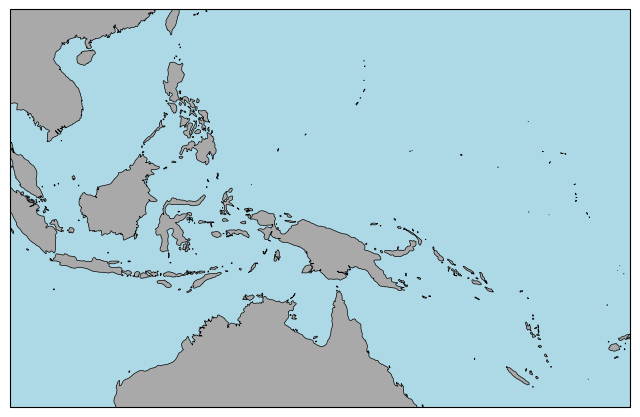

In [10]:
## Now lets look at what these lat/lon bounds look like
fig, ax = plt.subplots( figsize=(8, 8), subplot_kw={'projection': ccrs.Mercator()})

## add features
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAND, facecolor='darkgray')
ax.coastlines(linewidth=0.5)

## set domain to be just the area to the northwest of Svalbard
ax.set_extent([lon_e,lon_w,lat_s,lat_n],crs=ccrs.PlateCarree()) 

## Mean Precipitation Time Series 1950-2009

The following cells create visaulizations of the mean precipitation recieved in the region over the period of interest 1950-2009

:::{note}
Precipitation is in Kgm$^{-2}s^{-1}$ which isn't a very intuitive unit, so to convert to mm/day we can multiply by the number of seconds in a day 86400. One Kgm$^{-2} is equivalent to one mm.
:::

#### Time series of monthly precipitation 1950-2009 

The time series can be averaged over yearly time increments to better depict long term trends in precipitation.

In [11]:
## using the region defined in the above section lets take a slice of the data that only includes this region
pr_reg = pr_s.sel(lat=slice(lat_s, lat_n), lon=slice(lon_w, lon_e))

Text(0.5, 1.0, 'Average Precipitation over Oceania')

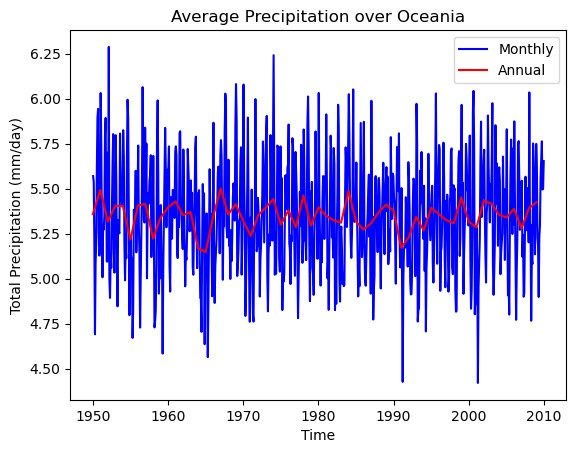

In [12]:
## Take the mean of all models over all lats and lons
region_mean_precip = pr_reg.mean(dim=['model','lat', 'lon'])*86400

## since its a bit hard to see trends with the seasonal cycle lets resample to annual data and overlay that
region_mean_precip_a = region_mean_precip.groupby('time.year').mean('time')

plt.plot(region_mean_precip.time,region_mean_precip,c='b',label='Monthly')
plt.plot(pd.to_datetime(region_mean_precip_a.year.astype(str)),region_mean_precip_a,c='r', label='Annual')
plt.ylabel("Total Precipitation (mm/day)")
plt.xlabel("Time")
plt.legend()
plt.title("Average Precipitation over Oceania")

:::{note}
This code does not account for latitude. A latitude weighted average would yield more accurate results, though the latitude range is not significant enough to cause significant errors. In the final project I plan to use latitude weighted averages
:::

Now lets look at the ensemble spread

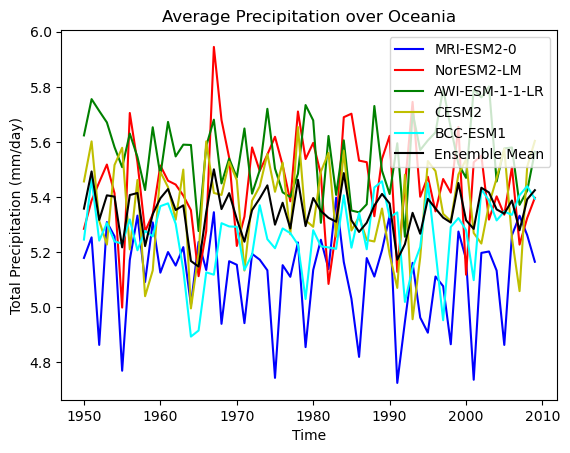

In [13]:
region_mean_precip_e = pr_reg.mean(dim=['lat', 'lon'])*86400

## make a list of colors to be used in the loop
c_list=['b','r','g','y','cyan']

## Get model names from datset strings
m_names = [s.split('.')[2] for s in pr_s.model.values]

for i in np.arange(0,5,1):
    p_a = region_mean_precip_e[i].groupby('time.year').mean('time')
    plt.plot(pd.to_datetime(p_a.year.astype(str)),p_a, c=c_list[i], label=m_names[i])
    
plt.plot(pd.to_datetime(region_mean_precip_a.year.astype(str)),region_mean_precip_a, c='k', label='Ensemble Mean')

## Make some visual improvements to the plot
#plt.ylim(2.1,2.7)
plt.ylabel("Total Precipitation (mm/day)")
plt.xlabel("Time")
plt.title("Average Precipitation over Oceania")
plt.legend(loc='upper right')


## Annual precipitation cycle

Average precipitation for each month over all years


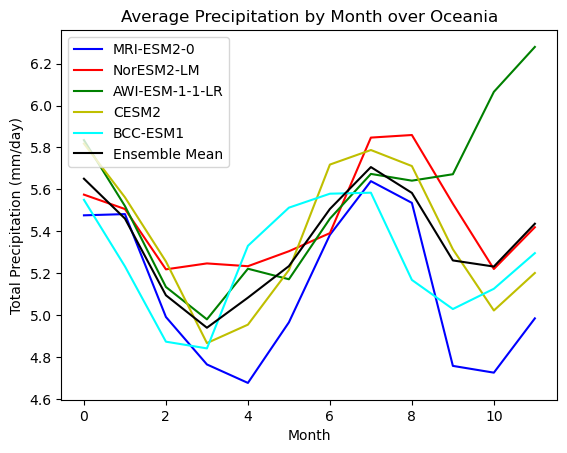

In [14]:
p_monthly = pr_reg.mean(dim=['lat', 'lon']).groupby('time.month').mean('time')*86400

for i in np.arange(0,5,1):
    plt.plot(p_monthly[i], c=c_list[i], label=m_names[i])

p_monthly_e = pr_reg.mean(dim=['model','lat', 'lon']).groupby('time.month').mean('time')*86400

plt.plot(p_monthly_e, c='k', label='Ensemble Mean')

## Make some visual improvements to the plot
plt.ylabel("Total Precipitation (mm/day)")
plt.xlabel("Month")
plt.title("Average Precipitation by Month over Oceania")
plt.legend(loc='upper left')

## Spatial pattern of average precipitation

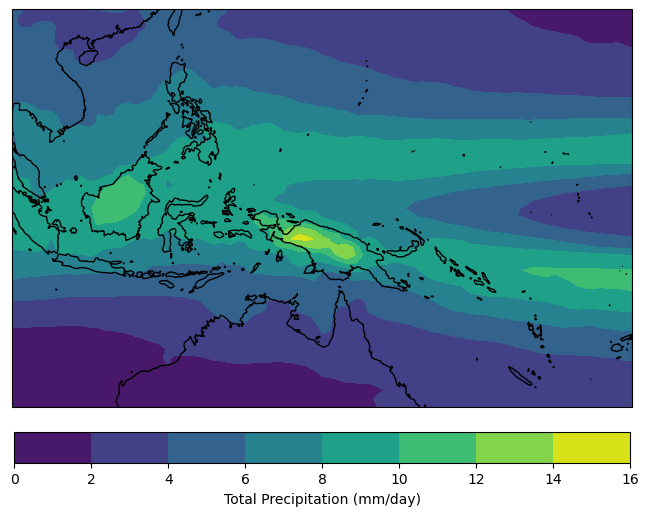

In [15]:
## Calculate mean
spatial_mean_precip = pr_s.mean(dim=['model','time'])

## Now lets plot this on a map
fig, ax = plt.subplots( figsize=(8, 8), subplot_kw={'projection': ccrs.Mercator()})

## add features
#ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
#ax.add_feature(cfeature.LAND, facecolor='darkgray')
ax.coastlines(linewidth=1)

## set domain to be just the area to the northwest of Svalbard
ax.set_extent([lon_e,lon_w,lat_s,lat_n],crs=ccrs.PlateCarree()) 

precip = ax.contourf(pr_s.lon,pr_s.lat,spatial_mean_precip*86400,transform=ccrs.PlateCarree())

cb = fig.colorbar(precip, ax=ax, orientation='horizontal', fraction=0.050, pad=0.04) 

cb.set_label("Total Precipitation (mm/day)")

Now we will compare average precipitation from the last 20 years (1990-2009) and first 20 years (1950-1969) of the time period. This provides a foundation for determining spatial patterns in preecipitation trends.

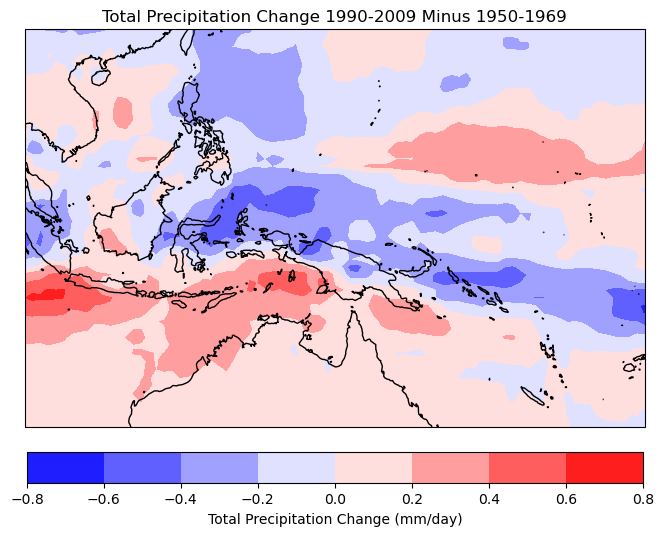

In [16]:
## Calculate difference between the two time periods
mean_p_5069 = pr_s.sel(time=slice("1950-01-01", "1969-12-31")).mean(dim=['model','time'])*86400
mean_p_9009 = pr_s.sel(time=slice("1990-01-01", "2009-12-31")).mean(dim=['model','time'])*86400
dif = mean_p_9009 - mean_p_5069

## Now lets plot this on a map
fig, ax = plt.subplots( figsize=(8, 8), subplot_kw={'projection': ccrs.Mercator()})

## add features
#ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
#ax.add_feature(cfeature.LAND, facecolor='darkgray')
ax.coastlines(linewidth=1)

## set domain to be just the area to the northwest of Svalbard
ax.set_extent([lon_e,lon_w,lat_s,lat_n],crs=ccrs.PlateCarree()) 

precip = ax.contourf(pr_s.lon,pr_s.lat,dif,transform=ccrs.PlateCarree(), cmap='bwr')

cb = fig.colorbar(precip, ax=ax, orientation='horizontal', fraction=0.050, pad=0.04) 

plt.title("Total Precipitation Change 1990-2009 Minus 1950-1969")
cb.set_label("Total Precipitation Change (mm/day)")

---

## Summary
CMIP6 data can be remotely loaded into Jupyter lab using Intake-ESM. This data can be subset to only include models and variables of interest. 

### What's next?
The 2_CMIP6_Precipitaion_VS_ERA5 notebook builds on some of the visualizations made in this notebook.

## Resources and references

Some useful links:
- CMIP6 Cookbook: https://projectpythia.org/cmip6-cookbook/